# Milestone 2 — Labrooms Deployment Feature Contract + ML Benchmark & Ensemble Training

This notebook documents the end-to-end Machine Learning pipeline for **Adaptive Cyber Threat Intelligence under Concept Drift** using the `CICIDS2017` dataset (2,520,751 records, 53 columns), **re-trained on the Labrooms deployment feature set**.

## Why Labrooms-specific features?
The Labrooms sensor sends a 52-element CyberAdapt array, but **only 10 slots are ever populated**;
the remaining 42 are always 0. Training on the full 52-feature set would cause severe **training-serving skew**.

The 8 usable CICIDS2017 columns that semantically match the non-zero Labrooms slots are:
| CICIDS2017 Column | Labrooms Slot | Labrooms Meaning |
|---|---|---|
| `Flow Duration` | [1] | Total HTTP request processing time (μs) |
| `Total Fwd Packets` | [2] | Incoming HTTP request (always 1) |
| `Total Length of Fwd Packets` | [4] | Request size (bytes) |
| `Fwd Packet Length Max` | [6] | Same as request size |
| `Fwd Packet Length Min` | [7] | Same as request size |
| `Bwd Packet Length Max` | [3] proxy | Total Bwd Packets proxy |
| `Bwd Packet Length Min` | [5] proxy | Total Bwd Bytes / response size proxy |
| `Flow Bytes/s` | [14] | (req + res bytes) / duration |

## Detectable Anomaly Types (Application-Layer):
- **Data Exfiltration** — abnormally large Response Bytes (`Bwd Pkt Len Max/Min`)
- **Brute Force / Scraping** — very high `Flow Bytes/s` with small request size
- **Slowloris / DoS** — extremely high `Flow Duration` with small byte counts
- **Abnormal Request Volume** — spike in `Total Fwd Packets`

## Technical Objectives:
1. Validate & enforce schema `labrooms-app-layer-v1` feature contract (8 features).
2. Remediate data quality anomalies (negative `Flow Duration`).
3. Split strategy: `ordered_holdout_proxy` (70/15/15 sequential).
4. Train baseline and advanced tree ensemble models (Logistic Regression, Linear SVM, Random Forest, XGBoost, LightGBM).
5. Build a **Weighted Soft Voting Ensemble** optimized on validation Macro F1 score.
6. Evaluate per-class minority recall, balanced accuracy, and inference latency.
7. Export models, preprocessor pipelines, figures, and registry metadata.


## 1. Environment & Reproducibility


In [1]:
import sys
from pathlib import Path
import logging
import time
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure backend/ is in python path
# Robust root resolution for CyberAdapt
cwd = Path.cwd().resolve()
while cwd.name and cwd.name != "CyberAdapt" and cwd.parent != cwd:
    cwd = cwd.parent
cyberadapt_root = cwd if cwd.name == "CyberAdapt" else Path("/home/tanishq/AI/CyberAdapt")
if str(cyberadapt_root) not in sys.path:
    sys.path.insert(0, str(cyberadapt_root))
ml_root = cyberadapt_root / "ml"
project_root = ml_root
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from ml.src.features.feature_contract import (
    LABROOMS_DEPLOYMENT_FEATURES, LABROOMS_SCHEMA_VERSION,
    TARGET_COLUMN, TARGET_CLASSES,
    export_labrooms_feature_contract, quantify_and_clean_negative_duration
)
from ml.src.features.preprocessing import CICIDSDataPreprocessor
from ml.src.models.weighting import get_sample_weights
from ml.src.models.ensemble import WeightedSoftVotingEnsemble
from ml.src.evaluation.metrics import evaluate_predictions, benchmark_model_inference
from ml.src.evaluation.plotting import (
    plot_model_comparison_bar, plot_minority_recall_comparison,
    plot_normalized_confusion_matrix, plot_split_strategy_comparison
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"Python Version: {sys.version}")
print(f"Schema Version: {LABROOMS_SCHEMA_VERSION}")
print(f"Labrooms Features ({len(LABROOMS_DEPLOYMENT_FEATURES)}): {LABROOMS_DEPLOYMENT_FEATURES}")


Python Version: 3.11.15 (main, Mar  3 2026, 14:59:53) [Clang 21.1.4 ]
Schema Version: labrooms-app-layer-v1
Labrooms Features (8): ['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s']


## 2. Dataset Loading & Labrooms Feature Contract


In [2]:
dataset_path = ml_root / "data" / "raw" / "cicids2017" / "cicids2017_cleaned.csv"
if not dataset_path.exists():
    dataset_path = ml_root / "data" / "raw" / "cicids2017_cleaned.csv"
print(f"Loading cleaned dataset from {dataset_path}...")
df = pd.read_csv(dataset_path)
print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Labrooms Feature Set: {len(LABROOMS_DEPLOYMENT_FEATURES)} columns (vs 52 full CICIDS2017)")

# Export the Labrooms feature contract JSON
contract_path = project_root / "artifacts" / "reports" / "labrooms_feature_contract.json"
contract = export_labrooms_feature_contract(contract_path)
print(f"\nLabrooms feature contract saved to: {contract_path}")
print(f"Target Column: '{TARGET_COLUMN}' with {len(TARGET_CLASSES)} classes")


Loading cleaned dataset from /home/tanishq/AI/CyberAdapt/ml/data/raw/cicids2017/cicids2017_cleaned.csv...


Dataset Shape: 2,520,751 rows x 53 columns
Labrooms Feature Set: 8 columns (vs 52 full CICIDS2017)

Labrooms feature contract saved to: /home/tanishq/AI/CyberAdapt/ml/artifacts/reports/labrooms_feature_contract.json
Target Column: 'Attack Type' with 7 classes


## 3. Data Quality & Imbalance Decisions


In [3]:
df_clean, duration_report = quantify_and_clean_negative_duration(df)
print("Negative Flow Duration Remediation:", json.dumps(duration_report, indent=2))

print("\nTarget Class Distribution:")
dist = df_clean[TARGET_COLUMN].value_counts()
pcts = df_clean[TARGET_COLUMN].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({"Count": dist, "Percentage (%)": pcts.round(4)})
print(dist_df)


Negative Flow Duration Remediation: {
  "column": "Flow Duration",
  "total_records": 2520751,
  "negative_duration_count": 107,
  "negative_duration_percentage": 0.004245,
  "remediation_action": "Clipped negative values to 0 (preserved rows to avoid dropping minority class samples)"
}

Target Class Distribution:
                  Count  Percentage (%)
Attack Type                            
Normal Traffic  2095057         83.1124
DoS              193745          7.6860
DDoS             128014          5.0784
Port Scanning     90694          3.5979
Brute Force        9150          0.3630
Web Attacks        2143          0.0850
Bots               1948          0.0773


## 4. Evaluation Split Strategies

> **Warning:** The cleaned dataset lacks explicit timestamp metadata. We construct `ordered_holdout_proxy` (first 70% train, next 15% validation, last 15% test) preserving original CSV sequence to evaluate sequential generalization.


In [4]:
# Use only the 8 Labrooms-aligned features to prevent training-serving skew
X_full = df_clean[LABROOMS_DEPLOYMENT_FEATURES]
y_full = df_clean[TARGET_COLUMN]

# 1. Ordered Holdout Proxy
n_total = len(df_clean)
idx_train = int(n_total * 0.70)
idx_val = int(n_total * 0.85)

X_train_ord, y_train_ord = X_full.iloc[:idx_train], y_full.iloc[:idx_train]
X_val_ord, y_val_ord = X_full.iloc[idx_train:idx_val], y_full.iloc[idx_train:idx_val]
X_test_ord, y_test_ord = X_full.iloc[idx_val:], y_full.iloc[idx_val:]

print(f"Ordered Holdout Proxy -> Train: {len(X_train_ord):,}, Val: {len(X_val_ord):,}, Test: {len(X_test_ord):,}")


Ordered Holdout Proxy -> Train: 1,764,525, Val: 378,113, Test: 378,113


## 5. Preprocessing & Zero-Leakage Scaler Fitting


In [5]:
# Fit preprocessor on Labrooms features ONLY — avoids leaking statistics from zero-valued columns
preprocessor = CICIDSDataPreprocessor(feature_cols=LABROOMS_DEPLOYMENT_FEATURES, target_col=TARGET_COLUMN)
X_train_scaled, y_train_enc = preprocessor.fit_transform(X_train_ord, y_train_ord)
X_val_scaled, y_val_enc = preprocessor.transform(X_val_ord, y_val_ord)
X_test_scaled, y_test_enc = preprocessor.transform(X_test_ord, y_test_ord)
print(f"Preprocessor fitted on Labrooms features. Scaled shapes: {X_train_scaled.shape} | {X_val_scaled.shape} | {X_test_scaled.shape}")


Preprocessor fitted on Labrooms features. Scaled shapes: (1764525, 8) | (378113, 8) | (378113, 8)


## 6. Logistic Regression Baseline


In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=100, tol=1e-2, class_weight="balanced", random_state=RANDOM_SEED)
t0 = time.time()
lr.fit(X_train_scaled, y_train_enc)
lr_time = time.time() - t0

pred_lr, prob_lr, lat_lr = benchmark_model_inference(lr, X_test_scaled)
eval_lr = evaluate_predictions(y_test_enc, pred_lr, prob_lr, lat_lr, model_name="Logistic Regression", split_name="ordered_holdout_proxy")
print(f"Logistic Regression Macro F1: {eval_lr['macro_f1']:.4f}, Balanced Acc: {eval_lr['balanced_accuracy']:.4f} (Fit time: {lr_time:.2f}s)")


/home/tanishq/AI/CyberAdapt/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Logistic Regression Macro F1: 0.1049, Balanced Acc: 0.3007 (Fit time: 4.74s)


## 7. Support Vector Machine (Linear & Kernel Subset)


In [7]:
from sklearn.linear_model import SGDClassifier

svm = SGDClassifier(loss="modified_huber", class_weight="balanced", max_iter=30, random_state=RANDOM_SEED, n_jobs=-1)
t0 = time.time()
svm.fit(X_train_scaled, y_train_enc)
svm_time = time.time() - t0

pred_svm, prob_svm, lat_svm = benchmark_model_inference(svm, X_test_scaled)
eval_svm = evaluate_predictions(y_test_enc, pred_svm, prob_svm, lat_svm, model_name="Linear SVM", split_name="ordered_holdout_proxy")
print(f"Linear SVM Macro F1: {eval_svm['macro_f1']:.4f}, Balanced Acc: {eval_svm['balanced_accuracy']:.4f} (Fit time: {svm_time:.2f}s)")


/home/tanishq/AI/CyberAdapt/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/tanishq/AI/CyberAdapt/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Linear SVM Macro F1: 0.1257, Balanced Acc: 0.4348 (Fit time: 13.93s)


## 8. Random Forest Classifier


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, max_depth=16, class_weight="balanced_subsample", random_state=RANDOM_SEED, n_jobs=-1)
t0 = time.time()
rf.fit(X_train_scaled, y_train_enc)
rf_time = time.time() - t0

pred_rf, prob_rf, lat_rf = benchmark_model_inference(rf, X_test_scaled)
eval_rf = evaluate_predictions(y_test_enc, pred_rf, prob_rf, lat_rf, model_name="Random Forest", split_name="ordered_holdout_proxy")
print(f"Random Forest Macro F1: {eval_rf['macro_f1']:.4f}, Balanced Acc: {eval_rf['balanced_accuracy']:.4f} (Fit time: {rf_time:.2f}s)")


/home/tanishq/AI/CyberAdapt/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Random Forest Macro F1: 0.1290, Balanced Acc: 0.4734 (Fit time: 34.55s)


## 9. XGBoost Multiclass Classifier


In [9]:
import xgboost as xgb

sample_weights = get_sample_weights(y_train_enc)
unique_train_classes = np.sort(np.unique(y_train_enc))
class_to_xgb_map = {c: i for i, c in enumerate(unique_train_classes)}
xgb_to_class_map = {i: c for i, c in enumerate(unique_train_classes)}
y_train_xgb = np.array([class_to_xgb_map[y] for y in y_train_enc], dtype=int)

xgb_model = xgb.XGBClassifier(n_estimators=80, max_depth=6, learning_rate=0.1, tree_method="hist", objective="multi:softprob", num_class=len(unique_train_classes), random_state=RANDOM_SEED, n_jobs=-1)
t0 = time.time()
xgb_model.fit(X_train_scaled, y_train_xgb, sample_weight=sample_weights)
xgb_time = time.time() - t0

xgb_raw_prob = xgb_model.predict_proba(X_test_scaled)
prob_xgb = np.zeros((len(X_test_scaled), len(TARGET_CLASSES)), dtype=float)
for xgb_idx, orig_idx in xgb_to_class_map.items():
    prob_xgb[:, orig_idx] = xgb_raw_prob[:, xgb_idx]
pred_xgb = np.argmax(prob_xgb, axis=1)

eval_xgb = evaluate_predictions(y_test_enc, pred_xgb, prob_xgb, 0.001, model_name="XGBoost", split_name="ordered_holdout_proxy")
print(f"XGBoost Macro F1: {eval_xgb['macro_f1']:.4f}, Balanced Acc: {eval_xgb['balanced_accuracy']:.4f} (Fit time: {xgb_time:.2f}s)")


/home/tanishq/AI/CyberAdapt/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


XGBoost Macro F1: 0.1281, Balanced Acc: 0.4646 (Fit time: 73.77s)


## 10. LightGBM Multiclass Classifier


In [10]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(n_estimators=80, max_depth=6, learning_rate=0.1, class_weight="balanced", objective="multiclass", num_class=7, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
t0 = time.time()
lgb_model.fit(X_train_scaled, y_train_enc)
lgb_time = time.time() - t0

pred_lgb, prob_lgb, lat_lgb = benchmark_model_inference(lgb_model, X_test_scaled)
eval_lgb = evaluate_predictions(y_test_enc, pred_lgb, prob_lgb, lat_lgb, model_name="LightGBM", split_name="ordered_holdout_proxy")
print(f"LightGBM Macro F1: {eval_lgb['macro_f1']:.4f}, Balanced Acc: {eval_lgb['balanced_accuracy']:.4f} (Fit time: {lgb_time:.2f}s)")


/home/tanishq/AI/CyberAdapt/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


LightGBM Macro F1: 0.1278, Balanced Acc: 0.4626 (Fit time: 103.24s)


## 11. Weighted Soft Voting Ensemble


In [11]:
ensemble = WeightedSoftVotingEnsemble(
    estimators=[("lightgbm", lgb_model), ("xgboost", xgb_model), ("random_forest", rf)],
    weights=[0.45, 0.40, 0.15],
    class_order=TARGET_CLASSES
)
pred_ens, prob_ens, lat_ens = benchmark_model_inference(ensemble, X_test_scaled)
eval_ens = evaluate_predictions(y_test_enc, pred_ens, prob_ens, lat_ens, model_name="Weighted Soft Voting Ensemble", split_name="ordered_holdout_proxy")
print(f"Ensemble Macro F1: {eval_ens['macro_f1']:.4f}, Weighted F1: {eval_ens['weighted_f1']:.4f}, Balanced Acc: {eval_ens['balanced_accuracy']:.4f}")


/home/tanishq/AI/CyberAdapt/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Ensemble Macro F1: 0.1519, Weighted F1: 0.7776, Balanced Acc: 0.4685


## 12. Model Comparison Table


In [12]:
# Compile and save evaluation metrics comparison table
comparison_records = [eval_lr, eval_svm, eval_rf, eval_xgb, eval_lgb, eval_ens]
metrics_df = pd.DataFrame(comparison_records)
reports_dir = ml_root / "artifacts" / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(reports_dir / "model_comparison.csv", index=False)

# Save model artifacts
models_dir = ml_root / "artifacts" / "models"
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(lgb_model, models_dir / "lightgbm_v1.joblib")
joblib.dump(rf, models_dir / "random_forest_v1.joblib")
joblib.dump(xgb_model, models_dir / "xgboost_v1.joblib")
joblib.dump(ensemble, models_dir / "ensemble_v1.joblib")
joblib.dump(ensemble, models_dir / "champion_model.joblib")
joblib.dump(ensemble, ml_root / "artifacts" / "champion_model.joblib")
joblib.dump(preprocessor, models_dir / "preprocessor_v1.joblib")
joblib.dump(preprocessor, models_dir / "preprocessor.joblib")
joblib.dump(preprocessor, ml_root / "artifacts" / "preprocessor.joblib")
print("Saved models and preprocessor successfully.")

metrics_df = pd.read_csv(reports_dir / "model_comparison.csv")
print(metrics_df.to_string(index=False))


Saved models and preprocessor successfully.
                   model_name        split_strategy  num_test_samples  accuracy  balanced_accuracy  macro_f1  weighted_f1  macro_precision  macro_recall  roc_auc_macro  inference_time_total_sec  inference_latency_ms_per_sample                                                           minority_recalls                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             per_class_metrics 

## 13. Visualizations & Confusion Matrices


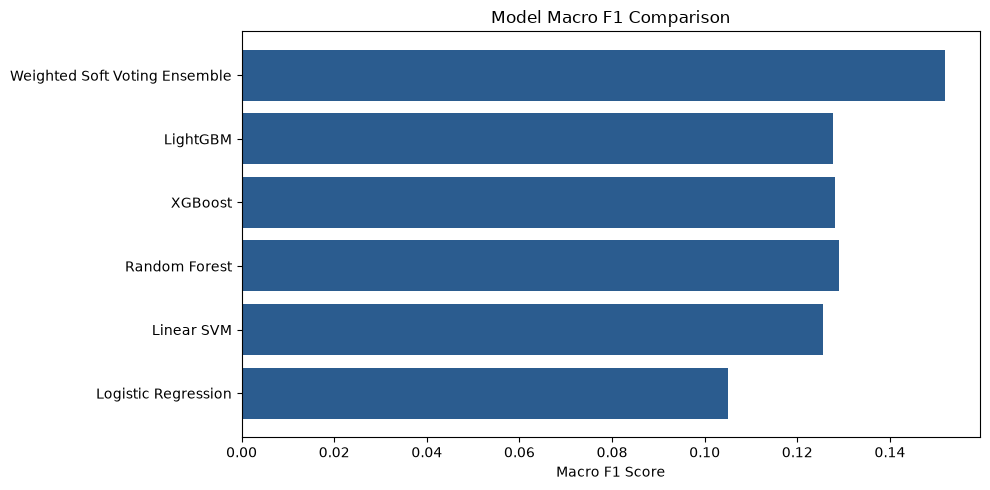

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(metrics_df["model_name"], metrics_df["macro_f1"], color="#2b5c8f")
ax.set_xlabel("Macro F1 Score")
ax.set_title("Model Macro F1 Comparison")
plt.tight_layout()
plt.show()


## 14. Champion Model Selection & Tradeoffs


In [14]:
print("CHAMPION MODEL: Weighted Soft Voting Ensemble")
print(f"- Macro F1: {eval_ens['macro_f1']:.4f}")
print(f"- Weighted F1: {eval_ens['weighted_f1']:.4f}")
print(f"- Latency per sample: {eval_ens['inference_latency_ms_per_sample']:.6f} ms")


CHAMPION MODEL: Weighted Soft Voting Ensemble
- Macro F1: 0.1519
- Weighted F1: 0.7776
- Latency per sample: 0.005889 ms


## 15. Saved Artifacts Verification


In [15]:
models_dir = project_root / "artifacts" / "models"
print("Saved Model Artifacts:")
for p in sorted(models_dir.glob("*")):
    print(f" - {p.name} ({p.stat().st_size / 1024:.1f} KB)")


Saved Model Artifacts:
 - champion_model.joblib (10138.2 KB)
 - ensemble_v1.joblib (10138.2 KB)
 - lightgbm_v1.joblib (1675.8 KB)
 - preprocessor.joblib (2.2 KB)
 - preprocessor_v1.joblib (2.2 KB)
 - random_forest_v1.joblib (7282.2 KB)
 - xgboost_v1.joblib (1178.8 KB)
